In [196]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score, confusion_matrix, precision_recall_curve

In [151]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [152]:
df_train

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [153]:
df_train.drop(df_train.columns[0], axis=1, inplace=True)
df_test.drop(df_test.columns[0], axis=1, inplace=True)

In [154]:
df_train

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,37.7175,-112.4777,258,Geoscientist,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,39.2667,-77.5101,100,"Production assistant, television",1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,32.9396,-105.8189,899,Naval architect,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,43.3526,-102.5411,1126,Volunteer coordinator,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0


In [155]:
#data types
print(df_train.dtypes)

trans_date_trans_time     object
cc_num                     int64
merchant                  object
category                  object
amt                      float64
first                     object
last                      object
gender                    object
street                    object
city                      object
state                     object
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                       object
dob                       object
trans_num                 object
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object


In [156]:
print(df_train.isnull().sum())
print(df_test.isnull().sum())

trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop       

In [157]:
print(df_train.shape)
print(f"Duplicate rows: {df_train.duplicated().sum()}")

print(df_test.shape)
print(f"Duplicate rows: {df_test.duplicated().sum()}")

(1296675, 22)
Duplicate rows: 0
(555719, 22)
Duplicate rows: 0


In [158]:
#check for class imbalance
print(df_train['is_fraud'].value_counts())
print(df_train['is_fraud'].value_counts(normalize=True) * 100)

is_fraud
0    1289169
1       7506
Name: count, dtype: int64
is_fraud
0    99.421135
1     0.578865
Name: proportion, dtype: float64


In [159]:
#some light feature eng
df_train['trans_date_trans_time'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['dob'] = pd.to_datetime(df_train['dob'])

df_train['trans_hour'] = df_train['trans_date_trans_time'].dt.hour
df_train['trans_dayofweek'] = df_train['trans_date_trans_time'].dt.dayofweek
df_train['trans_month'] = df_train['trans_date_trans_time'].dt.month
df_train['age'] = (df_train['trans_date_trans_time'] - df_train['dob']).dt.days // 365

print(df_train[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

#have to do it for test too
df_test['trans_date_trans_time'] = pd.to_datetime(df_test['trans_date_trans_time'])
df_test['dob'] = pd.to_datetime(df_test['dob'])

df_test['trans_hour'] = df_test['trans_date_trans_time'].dt.hour
df_test['trans_dayofweek'] = df_test['trans_date_trans_time'].dt.dayofweek
df_test['trans_month'] = df_test['trans_date_trans_time'].dt.month
df_test['age'] = (df_test['trans_date_trans_time'] - df_test['dob']).dt.days // 365

print(df_test[['trans_hour', 'trans_dayofweek', 'trans_month', 'age']].head())

   trans_hour  trans_dayofweek  trans_month  age
0           0                1            1   30
1           0                1            1   40
2           0                1            1   56
3           0                1            1   52
4           0                1            1   32
   trans_hour  trans_dayofweek  trans_month  age
0          12                6            6   52
1          12                6            6   30
2          12                6            6   49
3          12                6            6   32
4          12                6            6   65


In [160]:
df_train

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,...,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,trans_hour,trans_dayofweek,trans_month,age
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,...,1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,0,1,1,30
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,...,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,0,1,1,40
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,...,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,0,1,1,56
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,...,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,0,1,1,52
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,...,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,0,1,1,32
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296670,2020-06-21 12:12:08,30263540414123,fraud_Reichel Inc,entertainment,15.56,Erik,Patterson,M,162 Jessica Row Apt. 072,Hatch,...,1961-11-24,440b587732da4dc1a6395aba5fb41669,1371816728,36.841266,-111.690765,0,12,6,6,58
1296671,2020-06-21 12:12:19,6011149206456997,fraud_Abernathy and Sons,food_dining,51.70,Jeffrey,White,M,8617 Holmes Terrace Suite 651,Tuscarora,...,1979-12-11,278000d2e0d2277d1de2f890067dcc0a,1371816739,38.906881,-78.246528,0,12,6,6,40
1296672,2020-06-21 12:12:32,3514865930894695,fraud_Stiedemann Ltd,food_dining,105.93,Christopher,Castaneda,M,1632 Cohen Drive Suite 639,High Rolls Mountain Park,...,1967-08-30,483f52fe67fabef353d552c1e662974c,1371816752,33.619513,-105.130529,0,12,6,6,52
1296673,2020-06-21 12:13:36,2720012583106919,"fraud_Reinger, Weissnat and Strosin",food_dining,74.90,Joseph,Murray,M,42933 Ryan Underpass,Manderson,...,1980-08-18,d667cdcbadaaed3da3f4020e83591c83,1371816816,42.788940,-103.241160,0,12,6,6,39


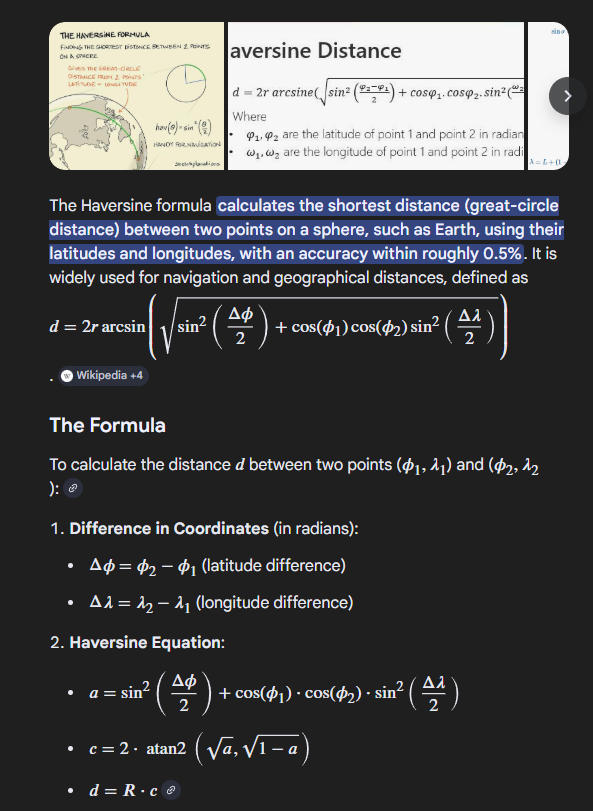

In [161]:
#more feature engineering
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return R * 2 * np.arcsin(np.sqrt(a)) #guys rememer that atan can be written using arcsin

df_train['distance_km'] = haversine_distance(
    df_train['lat'], df_train['long'], df_train['merch_lat'], df_train['merch_long']
)

df_test['distance_km'] = haversine_distance(
    df_test['lat'], df_test['long'], df_test['merch_lat'], df_test['merch_long']
)

print(df_train.groupby('is_fraud')['distance_km'].mean())
#rough this means that distance is not a strong signal for it which I was hoping that it would be.

is_fraud
0    76.113756
1    76.268330
Name: distance_km, dtype: float64


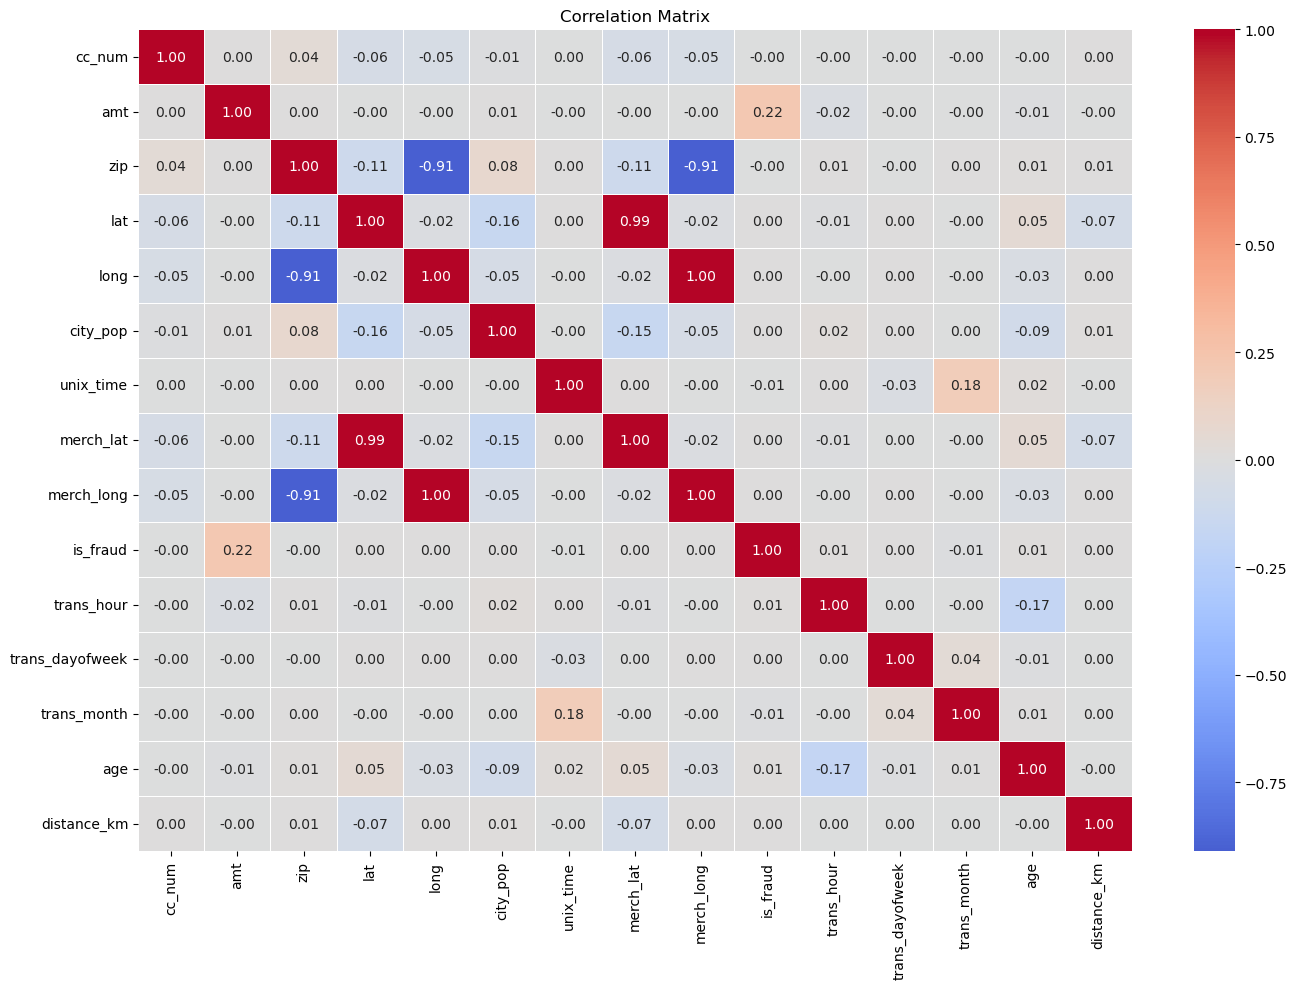

In [162]:
numeric_cols = df_train.select_dtypes(include=np.number).columns.tolist()

corr = df_train[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()

bunch of multicolinear stuff so we gonna drop those and some of them have different ways of encoding stuff so those really have no meaning so I shall be dropping those too

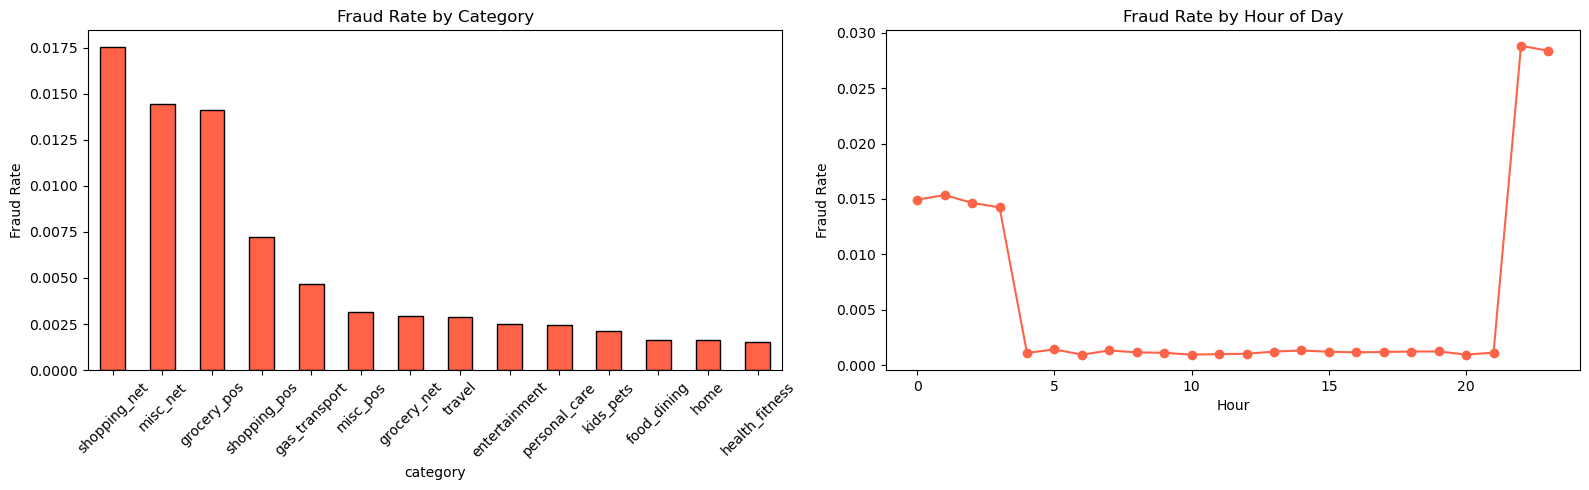

In [163]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

df_train.groupby('category')['is_fraud'].mean().sort_values(ascending=False).plot.bar(
    ax=axes[0], color='tomato', edgecolor='black')
axes[0].set_title('Fraud Rate by Category')
axes[0].set_ylabel('Fraud Rate')
axes[0].tick_params(axis='x', rotation=45)

df_train.groupby('trans_hour')['is_fraud'].mean().plot(
    ax=axes[1], marker='o', color='tomato')
axes[1].set_title('Fraud Rate by Hour of Day')
axes[1].set_xlabel('Hour')
axes[1].set_ylabel('Fraud Rate')

plt.tight_layout()
plt.show()

damn the scammers really working overtime at night

In [164]:
print(f"Unique cities: {df_train['city'].nunique()}")
print(f"Unique states: {df_train['state'].nunique()}")

Unique cities: 894
Unique states: 51


In [165]:
cols_to_drop = [
    'cc_num', # ID, zero correlation with fraud ngl
    'trans_num', # type of ID it has no signal
    'first', 'last', 'street', #personal info I dont think this has any yse
    'unix_time', # 0.99 corr with trans_month it is redundant
    'dob', # extracted age already
    'trans_date_trans_time', # extracted hour, day, month already
    'lat', 'long', # 0.99 corr with merch_lat/long, captured in distance_km
    'merch_lat', 'merch_long',
    'zip', # -0.91 corr with long, redundant location info
    'merchant',# too many unique values, high cardinality might KEEEP??? later
    'job', 'city' #no signal, I just use state, city might blow up feature space we could try with this alter tho
]

df_train.drop(columns=cols_to_drop, inplace=True)
df_test.drop(columns=cols_to_drop, inplace=True)

print(df_train.columns.tolist())
print(df_train.shape)

['category', 'amt', 'gender', 'state', 'city_pop', 'is_fraud', 'trans_hour', 'trans_dayofweek', 'trans_month', 'age', 'distance_km']
(1296675, 11)


In [166]:
from sklearn.preprocessing import LabelEncoder

labelencoderrr = LabelEncoder()

for col in ['category', 'gender', 'state']:
    df_train[col] = labelencoderrr.fit_transform(df_train[col])
    df_test[col] = labelencoderrr.transform(df_test[col]) #you only transform on test, keep things consistent. If the data appears in different order then it transforms differently if you fit again

print(df_train.head())
print(df_train.dtypes)

   category     amt  gender  state  city_pop  is_fraud  trans_hour  \
0         8    4.97       0     27      3495         0           0   
1         4  107.23       0     47       149         0           0   
2         0  220.11       1     13      4154         0           0   
3         2   45.00       1     26      1939         0           0   
4         9   41.96       1     45        99         0           0   

   trans_dayofweek  trans_month  age  distance_km  
0                1            1   30    78.597568  
1                1            1   40    30.212176  
2                1            1   56   108.206083  
3                1            1   52    95.673231  
4                1            1   32    77.556744  
category             int64
amt                float64
gender               int64
state                int64
city_pop             int64
is_fraud             int64
trans_hour           int32
trans_dayofweek      int32
trans_month          int32
age                  int

In [167]:
X_train = df_train.drop(columns=['is_fraud'])
y_train = df_train['is_fraud']

X_test = df_test.drop(columns=['is_fraud'])
y_test = df_test['is_fraud']

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"\ny_train distribution:\n{y_train.value_counts()}")
print(f"\ny_test distribution:\n{y_test.value_counts()}")

X_train: (1296675, 10)
X_test: (555719, 10)

y_train distribution:
is_fraud
0    1289169
1       7506
Name: count, dtype: int64

y_test distribution:
is_fraud
0    553574
1      2145
Name: count, dtype: int64


In [168]:
smote = SMOTE(random_state=67) #67 meme fr
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print(f"Before SMOTE: {y_train.value_counts().to_dict()}")
print(f"After SMOTE: {pd.Series(y_train_resampled).value_counts().to_dict()}")

Before SMOTE: {0: 1289169, 1: 7506}
After SMOTE: {0: 1289169, 1: 1289169}


hurray everything equal yall can get to modelling rn

In [ ]:
clf = DecisionTreeClassifier(
    criterion='entropy',
    random_state=67,
    class_weight='balanced'
)

clf.fit(X_train_resampled, y_train_resampled)
y_pred = clf.predict(X_test)

print("Decision Tree:")
print(classification_report(y_test, y_pred))

Decision Tree:
              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.26      0.81      0.39      2145

    accuracy                           0.99    555719
   macro avg       0.63      0.90      0.69    555719
weighted avg       1.00      0.99      0.99    555719



In [ ]:
clf_forr = RandomForestClassifier(
    n_estimators=200,
    random_state=67,
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1
)

clf_forr.fit(X_train_resampled, y_train_resampled)
y_pred2 = clf_forr.predict(X_test)

print("Random Forest:")
print(classification_report(y_test, y_pred2))

Random Forest:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.60      0.82      0.69      2145

    accuracy                           1.00    555719
   macro avg       0.80      0.91      0.84    555719
weighted avg       1.00      1.00      1.00    555719



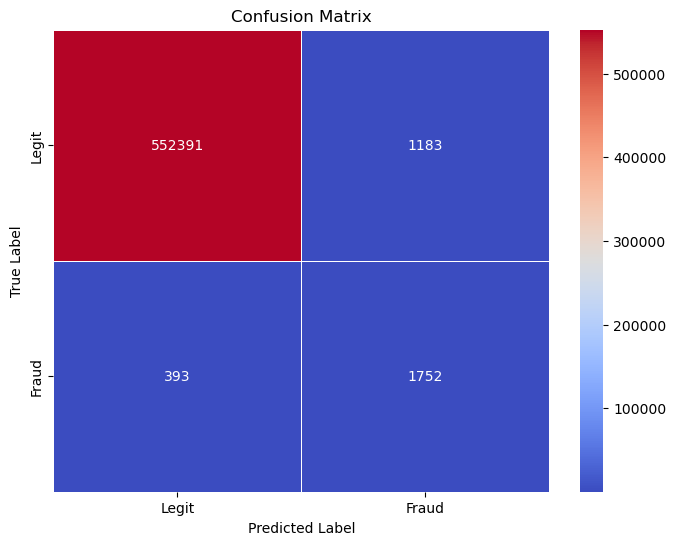

In [216]:
cm = confusion_matrix(y_test, y_pred2)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], linewidths=0.5)

plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
y_proba = clf_forr.predict_proba(X_test)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_test, y_proba)


best_f1 = 0
best_threshold = 0

for threshold in thresholds:
    y_pred_temp = (y_proba >= threshold).astype(int)
    f1 = f1_score(y_test, y_pred_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = threshold

print(f"Optimal threshold: {best_threshold:.3f}")
print(f"Optimal F1-score: {best_f1:.3f}")

y_pred_tuned = (y_proba >= best_threshold).astype(int)

print("\nRandom Forest (tuned):")
print(classification_report(y_test, y_pred_tuned))

Optimal threshold: 0.765
Optimal F1-score: 0.750

Random Forest (tuned):
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    553574
           1       0.81      0.70      0.75      2145

    accuracy                           1.00    555719
   macro avg       0.90      0.85      0.87    555719
weighted avg       1.00      1.00      1.00    555719



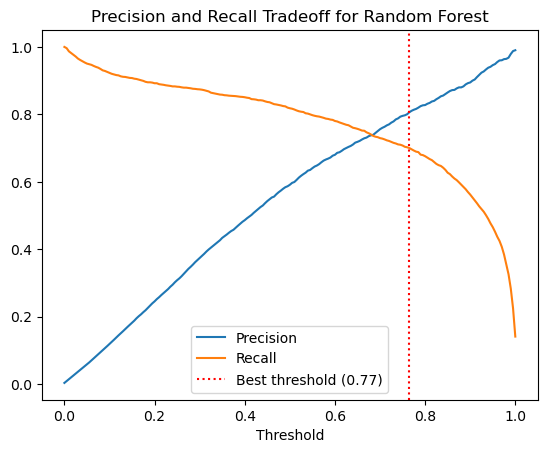

In [ ]:
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.axvline(best_threshold, color='red', linestyle=':', label=f'Best threshold ({best_threshold:.2f})')

plt.xlabel('Threshold')
plt.legend()
plt.title('Precision and Recall Tradeoff for Random Forest')
plt.show()

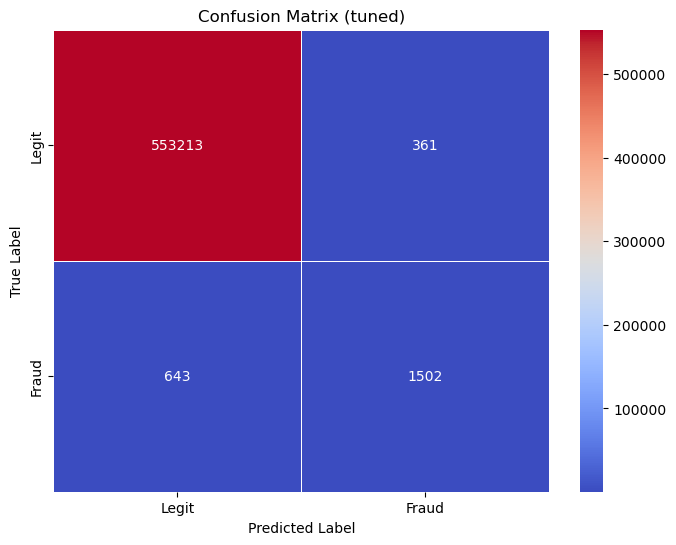

In [ ]:
cm2 = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(8, 6))
sns.heatmap(cm2, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], linewidths=0.5)

plt.title('Confusion Matrix (tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

After the tuning, False Postives dropped massively (from 1183 to 361), but False Negatives (missed fraud) increased to almost double (393 to 643).

In [ ]:
# Manually set a lower threshold
y_pred_test = (y_proba >= 0.3).astype(int)
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

           0       1.00      0.99      1.00    553574
           1       0.37      0.87      0.52      2145

    accuracy                           0.99    555719
   macro avg       0.69      0.93      0.76    555719
weighted avg       1.00      0.99      1.00    555719



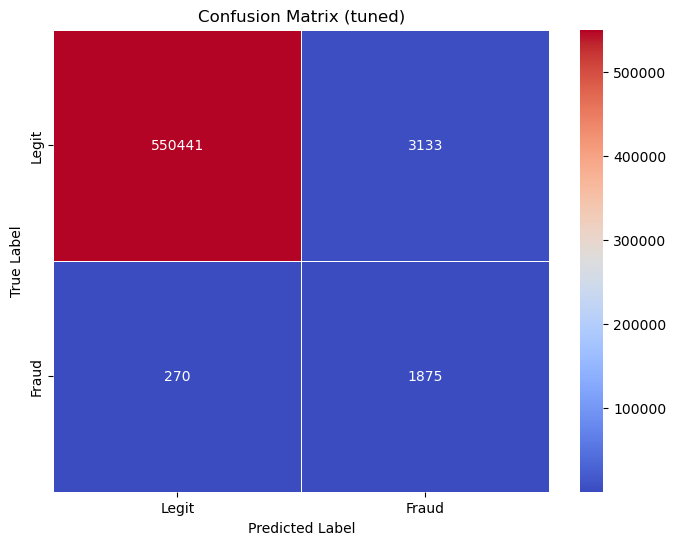

In [ ]:
cm3 = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
sns.heatmap(cm3, cmap='coolwarm', annot=True, fmt='d', xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'], linewidths=0.5)

plt.title('Confusion Matrix (tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

Best results so far. 3133 False Positives out of 553574 legit transactions (0.57%).